<a href="https://colab.research.google.com/github/alexyh1/STA4000/blob/main/code/monge/1.5_Knothe_Transport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The following code is a reproduction of the Knothe-Rosenblatt Triangular Rearrangement as described in Villani (2009) from STA4000 Supervised Reading Project: Optimal Transport for Machine Learners. More examples can be found here: https://github.com/alexyh1/STA4000/tree/main/code

See the [previous exercise](https://github.com/alexyh1/STA4000/blob/main/code/McCann_Interpolation.ipynb) for a quick recap of Monge's optimal transport formulation.

Peyré (2026) outlines the existence of a triangular map between two probability measures under certain regularity conditions. The proof is recursive and omitted for brevity (Proposition 2.35).

**Proposition 2.35:** Let $\mu, \nu \in \mathcal{M}_1^+(\mathbb{R}^d)$ and assume that the first marginal of $\mu$ is atomless and that regular conditional distributions are fixed. Then there exists a triangular map $$T(x_1, ..., x_d) = (T_1(x_1), T_2(x_1, x_2), ..., T_d(x_1, ..., x_d))$$

Such that $T_\# \mu = \nu$ and $x_k → T_k$ is non-decreasing for $\mu$-almost every value of $(x_1, ..., x_{k-1})$.

We proceed with a simple numerical example between two anisotropic Gaussian distributions $$X \sim N(\mu_x, \begin{bmatrix}
1 & \rho_x \\
\rho_x & 1
\end{bmatrix}), \ Y \sim N(\mu_y, \begin{bmatrix}
1 & \rho_y \\
\rho_y & 1
\end{bmatrix})$$
Where $\mu_x = \begin{bmatrix}
-2 \\
-2
\end{bmatrix}$, $\mu_y = \begin{bmatrix}
4 \\
4
\end{bmatrix}$, $\rho_x = 0.8$ and $\rho_y = -\rho_x$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
import time

start_time = time.time()
# Generate MVN distributions
np.random.seed(4000)
n = 20000
rho_x = 0.8
rho_y = -0.8
S_1 = np.array([[1, rho_x], [rho_x, 1]])
S_2 = np.array([[1, rho_y], [rho_y, 1]])

X = np.random.multivariate_normal(-2*np.ones(2), S_1, n)
Y = np.random.multivariate_normal(4*np.ones(2), S_2, n)

Step 1 of the algorithm described in Villani is to take the first marginal distributions $\mu_1(dx_1), \nu_1(dy_1)$ where $\mu$ is atomless. Then define y_1 = T1(x1) by the formula for the increasing
rearrangement (1D closed-form transport solution) given by $T = \mathcal{C}_{\nu_1}^{-1} \circ \mathcal{C}_{\mu_1}$; here we use estimated cdf and quantile functions from our generated samples; regularity conditions hold for sufficiently large $n$.

In [ ]:
# Step 1: Compute first marginals
X_1 = X[:, 0]
Y_1 = Y[:, 0]

def transport_1d(source, target):
    source_ecdf = stats.ecdf(source).cdf
    def T(x):
        p = source_ecdf.evaluate(x)
        return np.quantile(target, p, method="inverted_cdf")
    return T

T_1 = transport_1d(X_1, Y_1)
Y_1KR = T_1(X_1)

Step 2 of Villani outlines the construction of the second triangular coordinate, using $y_1 = T_1(x_1)$ from step 1 and $y_2 = T_2(x_1, x_2)$ is the closed-form map of the conditional second marginals $\mu_2(dx_2|x_1)$ into $\nu_2(dy_2|y_1)$. Then our triangular map takes the form of $T = (T_1, T_2)$, satisfying the push-forward constraint.

In [ ]:
# Step 2: Conditional rearrangement
# X2 | X1 = x1 ~ N(rho_x*x1, 1-rho_x^2)
# Y2 | Y1 = y1 ~ N(rho_y*y1, 1-rho_y^2)

X_2 = X[:, 1]
# CDF of X2 | X1 = x1
u = norm.cdf((X_2 - rho_x*X_1) / np.sqrt(1 - rho_x**2))

# Quantile of Y2 | Y1_KR = T1(x1)
Y2_KR = (rho_y * Y_1KR + np.sqrt(1 - rho_y**2) * norm.ppf(u))

T = np.column_stack((Y_1KR, Y2_KR))

Below are the 2d projections of the Gaussian samples; can proceed with statistical inference on the OT-estimated map (See Chewi 2024).

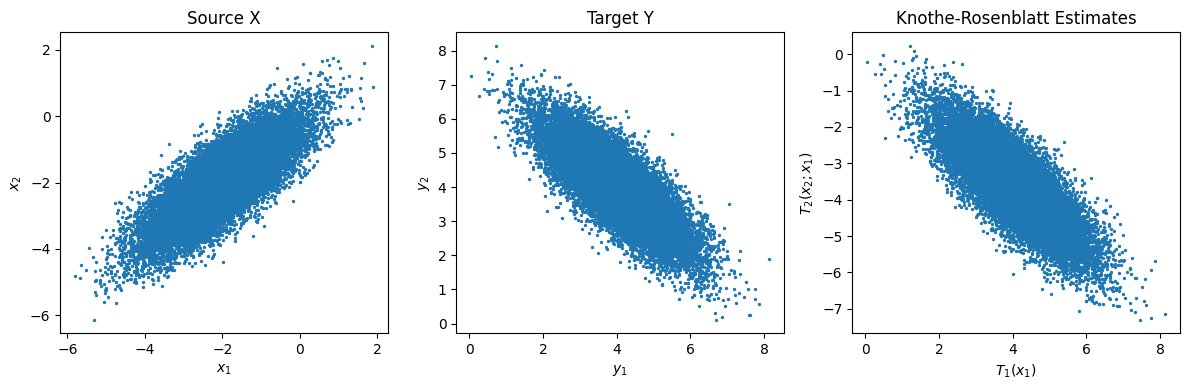

In [ ]:
fig, axes = plt.subplots(1, 3, figsize = (12, 4))

axes[0].scatter(X[:,0], X[:,1], s = 2)
axes[0].set_title("Source X")
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")

axes[1].scatter(Y[:,0], Y[:,1], s = 2)
axes[1].set_title("Target Y")
axes[1].set_xlabel("$y_1$")
axes[1].set_ylabel("$y_2$")

axes[2].scatter(T[:,0], T[:,1], s = 2)
axes[2].set_title("Knothe-Rosenblatt Estimates")
axes[2].set_xlabel("$T_1(x_1)$")
axes[2].set_ylabel("$T_2(x_2;x_1)$")

plt.tight_layout()
plt.show()

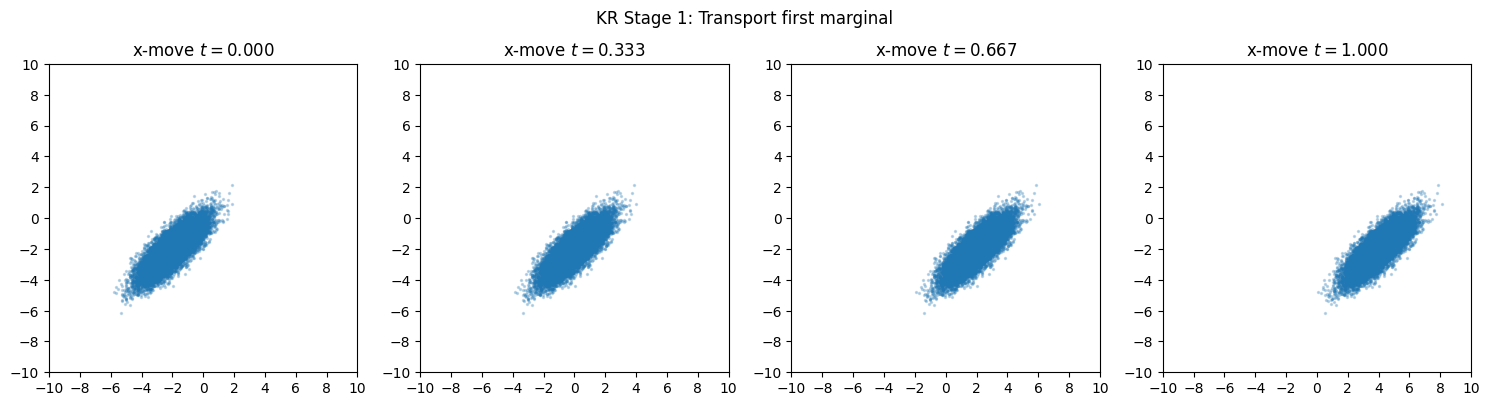

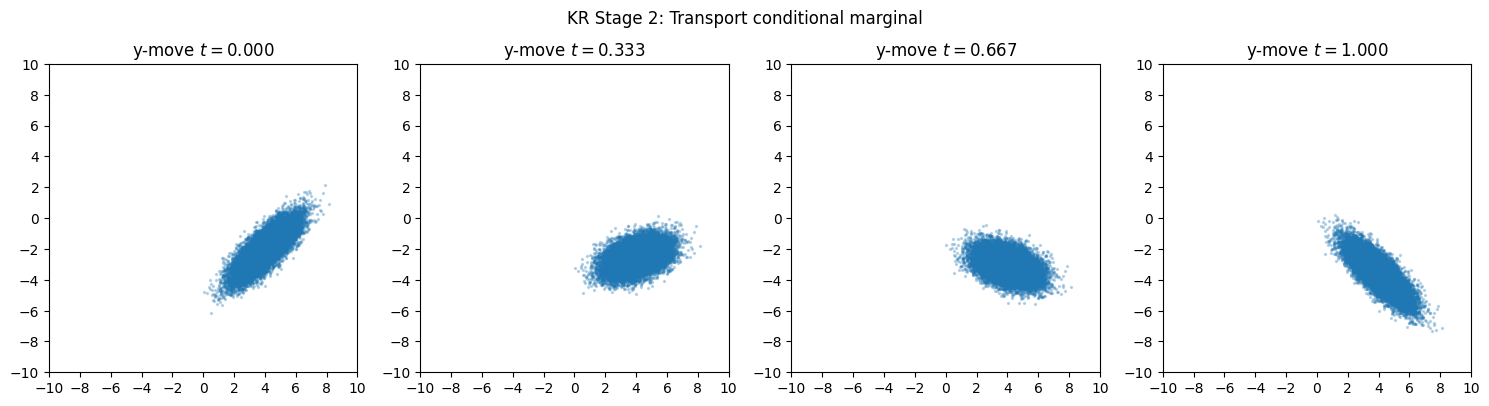

In [ ]:
times = np.linspace(0, 1, num = 4)
ticks = np.arange(-10, 11, step = 2)
fig, axs = plt.subplots(1, 4, figsize = (15, 4))

for t, ax in zip(times, axs):
    Z = np.column_stack([(1-t)*X[:,0] + t*Y_1KR, X[:,1]])

    ax.scatter(Z[:,0], Z[:,1], s=2, alpha=0.25)
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)
    ax.set_aspect("equal")
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_title(f"x-move $t={t:.3f}$")

plt.suptitle("KR Stage 1: Transport first marginal")
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 4, figsize=(15, 4))

for t, ax in zip(times, axs):
    Z = np.column_stack([Y_1KR, (1-t)*X[:,1] + t*Y2_KR])

    ax.scatter(Z[:,0], Z[:,1], s=2, alpha=0.25)
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)
    ax.set_aspect("equal")
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_title(f"y-move $t={t:.3f}$")

plt.suptitle("KR Stage 2: Transport conditional marginal")
plt.tight_layout()
plt.show()

The figure illustrates KR transport interpolation (x-move $→$ pivot $→$ y-move); intuitively, the triangular map is also referred as the axis-wise transport solution. The Knothe map is often suboptimal but serves as an instructional example for visualizing snapshots of mass transportion.

In [ ]:
end_time = time.time()
print(f"Program runtime: {end_time - start_time:.3f} seconds.")

Program runtime: 2.186 seconds.


##**References**
[1] G. Peyré (2026). [*Optimal Transport for Machine Learners*.](https://arxiv.org/pdf/2505.06589) arXiv preprint arXiv:2505.06589.

[2] C. Villani (2009). [Optimal Transport: Old and New](https://www.ceremade.dauphine.fr/~mischler/articles/VBook-O&N.pdf). Springer.

[3] S. Chewi, J. Niles-Weed, P. Rigollet (2024). [Statistical Optimal Transport](https://arxiv.org/pdf/2407.18163). arXiv preprint arXiv:2407.18163.

[4] H. Knothe (1957). [Contributions to the theory of convex bodies](https://scispace.com/pdf/contributions-to-the-theory-of-convex-bodies-4xaelx1q8d.pdf). Michigan Mathematical Journal 4(1):39–52.

[5] M. Rosenblatt (1952). [Remarks on a multivariate transformation](https://scispace.com/pdf/remarks-on-a-multivariate-transformation-580hmbpjf8.pdf). The Annals of Mathematical Statistics 23(3):470–472.
